# Heatmaps — sites × timepoints

Two views of the same phosphosites, drawn by `plot_fc_heatmap()` and `plot_step_heatmap()`
(`src/plotting_functions.py`). Both put **timepoints on the x-axis**, **sites on the y-axis**,
and one panel per condition; they differ only in what the colour means.

| function | colour | question it answers |
|---|---|---|
| `plot_fc_heatmap` | `log2:FC` — value vs the starve control | *where is this site now, relative to baseline?* |
| `plot_step_heatmap` | `log2:step` — value minus the previous timepoint | *what changed during this interval?* |

The distinction matters for reading dynamics. A site that jumps at 2 min and then holds is
**strong at every timepoint** in the FC heatmap (it never returns to baseline) but shows **one
strong cell at 2 min and near-white afterwards** in the step heatmap. Sustained and transient
responses look alike in FC and completely different in step.

Both functions share the same row selection, row ordering and symmetric colour scale, so the
two figures of the same site set are directly comparable — same site on the same row.

`plot_fc_step_heatmap()` draws the two of them **side by side as two subfigures** of one figure,
which is the form to use when the point is the comparison itself (section 3).


In [1]:
import matplotlib.pyplot as plt

from src.column_spec import *
from src.plotting_functions import *

from src.transformations import log2_step_size
from src.filters import filter_by_ffdr, filter_dynamics, filter_incomplete_timeseries

## Load the data and build `log2:step`

`log2:step` is not stored in the processed table yet — it is computed by `log2_step_size()` in
`notebooks/01_preprocessing/TMT_dataset_preprocessing.ipynb`. Recompute it here so this notebook
is self-contained; drop the two cells below if you re-save the processed file with the step
columns already in it.

No `.fillna(0)` on load: this table carries the limma statistics columns, where NaN means
"limma could not test this site" and 0.0 would read as perfectly significant.

In [2]:
# hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260814_hTERT_HEM1_2_processed_phPlus.tsv",
#                      sep="\t",
#                      low_memory=False,)

CELL_LINE = "WT"
CONDITIONS = ['_EGF_']# , '_INS_', '_EGFnINS_']

# A step joins two timepoints, so one missing log2:FC blanks two step columns. On hme1_2 this
# is 4 sites, all n:reps == 1 (see the preprocessing notebook).
# hme1_2 = filter_incomplete_timeseries(hme1_2,
#                                       cell_lines=[CELL_LINE],
#                                       conditions=CONDITIONS,
#                                       data_type="log2:FC",
#                                       exclude_full=True,
#                                       max_missing=0,)
# hme1_2 = log2_step_size(hme1_2,
#                         cell_line=CELL_LINE,
#                         conditions=CONDITIONS,)
# print(hme1_2.shape)
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260817_hTERT_HEM1_2_log2_processed.tsv",
                     sep="\t",
                     low_memory=False,)
MAPK_PROTEINS = ["EGFR", "GAB1", "SOS1", "BRAF", "MAP2K1", "MAPK1", "MAPK3", "RPS6KA3"]


In [3]:
# Where the exported figures go. Defined here because the cells below save into it.
# RUN_NAME = f"{date.today().strftime('%Y%m%d')}_heatmaps_hme1_2"
# SAVING_PATH = f"Results/{RUN_NAME}_files"

## Side-by-side comparison

`plot_fc_step_heatmap()` puts the two blocks in one figure: **log2:FC on the left** (red/blue),
**log2:step on the right** (green/purple). The rows are selected once and ordered once, so a
row means the same site in both halves and can be read straight across — *where the site
stands* on the left, *the movement that put it there* on the right.

The two blocks carry **separate colour scales and separate colorbars**: a fold change against
baseline and an increment between two timepoints are different quantities, and forcing them
onto one scale would only make the steps look small. Do not read one colorbar against the other.

`sort_on=` picks which half decides the row order:

- `"log2:FC"` (default) — groups sites by response *shape*; the step block then shows where
  each shape's movement sits.
- `"log2:step"` — groups sites by *when* they move; the FC block then shows what that timing
  adds up to.
- `"both"` — orders on the two concatenated.

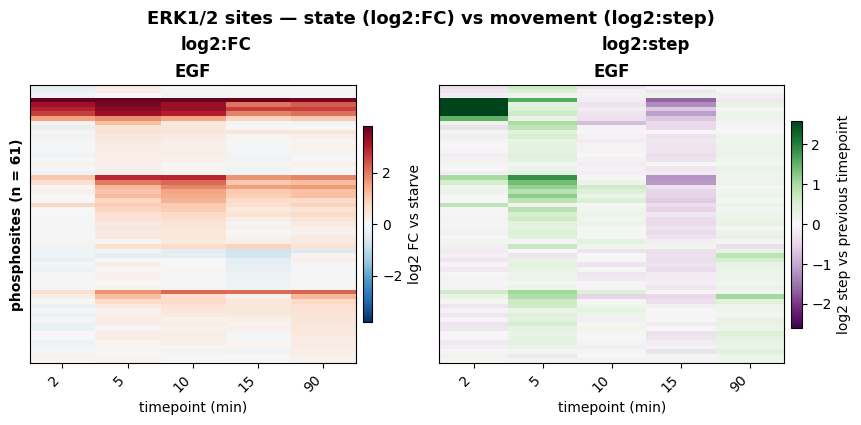

{'log2:FC': (61, 5), 'log2:step': (61, 5)}
same row order: True


In [4]:
fig, matrices = plot_fc_step_heatmap(hme1_2,
                                    cell_line=CELL_LINE,
                                    conditions=CONDITIONS,
                                    proteins=["EGFR", "BRAF", "MAPK3"],
                                    timepoints=["2", "5", "10", "15", "90"],
                                    sort_by="peak",
                                    sort_on="log2:FC",
                                    title="ERK1/2 sites — state (log2:FC) vs movement (log2:step)",)

# Both halves come back keyed by data type, in the shared row order.
print({name: matrix.shape for name, matrix in matrices.items()})
print("same row order:", list(matrices["log2:FC"].index) == list(matrices["log2:step"].index))

## Filtering dataset

`max_sites` (default 300) refuses to draw a figure with more rows than can be read; it is a
guard, not a limit — set it to `None` to override. The useful move is to filter to the sites
worth looking at first, with the same chain the clustering notebooks use:

1. `filter_by_nreps` — detected in enough replicates
2. `filter_dynamics` — moved by at least `MIN_FC`
3. `filter_by_ffdr` — limma's omnibus F calls it responsive (the reproducibility criterion)

Above ~60 rows the site labels are dropped automatically and the figure switches to a compact
row height, so a few hundred sites still render as a readable block.

In [5]:
responsive = filter_by_ffdr(hme1_2,
                            cell_lines=[CELL_LINE],
                            conditions=["_EGF_"],
                            max_ffdr=0.05,
                            verbose=True,)
responsive = filter_dynamics(responsive,
                             cell_lines=[CELL_LINE],
                             conditions=["_EGF_"],
                             data_type="log2:FC",
                             threshold=1,
                             mode="extremes",)
print(f"sites kept: {len(responsive)}")

FFDR < 0.05 (any of WT_log2:FFDR_EGF_omnibus): 20853 of 50002 sites kept (29149 dropped, of which 16283 never tested by limma)
sites kept: 2105


In [6]:
top_sites = (responsive
             .assign(_amplitude=responsive[ColumnSpec.select(responsive,
                                                             cell_lines=[CELL_LINE],
                                                             data_type="log2:FC",
                                                             conditions=["_EGF_"],
                                                             exclude_full=True,)].abs().max(axis=1))
             .nlargest(200, "_amplitude")["site"].tolist())

saving_path is empty — plot not saved


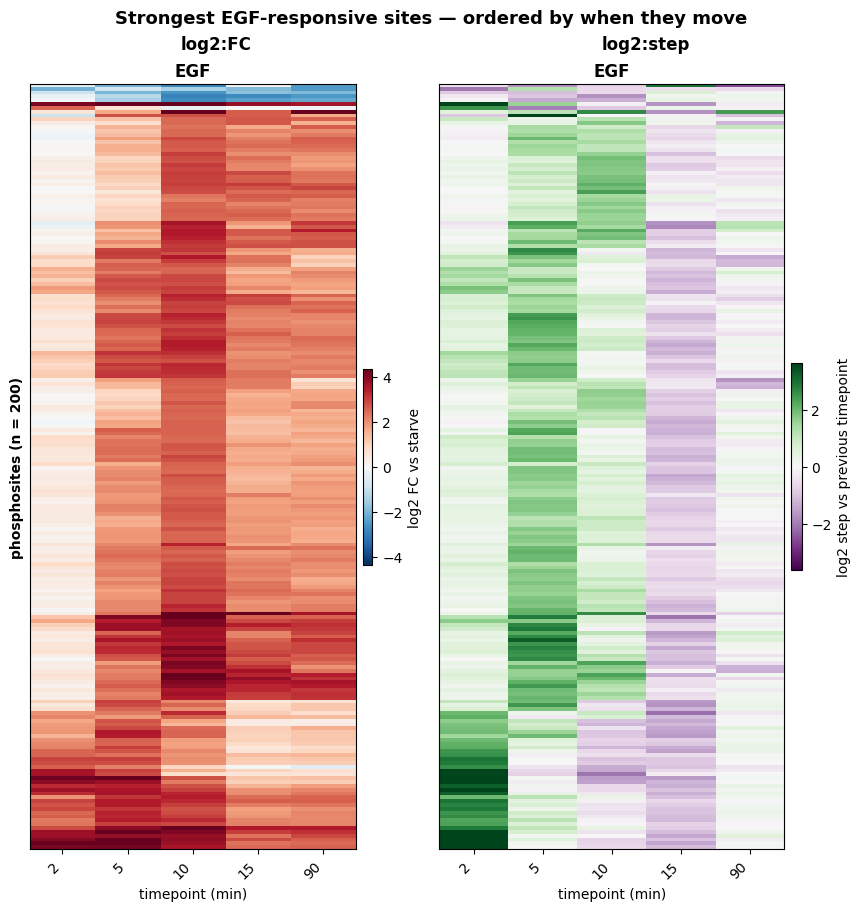

In [7]:
fig, matrices = plot_fc_step_heatmap(hme1_2,
                                    cell_line=CELL_LINE,
                                    conditions=["_EGF_"],
                                    sites=top_sites,
                                    timepoints=["2", "5", "10", "15", "90"],
                                    sort_by="hierarchical",
                                    max_sites=None,
                                    sort_on="log2:FC",
                                    title="Strongest EGF-responsive sites — ordered by when they move",
                                    saving_path=None,
                                    saving_info="fc_vs_step",
                                    save_png=True,)

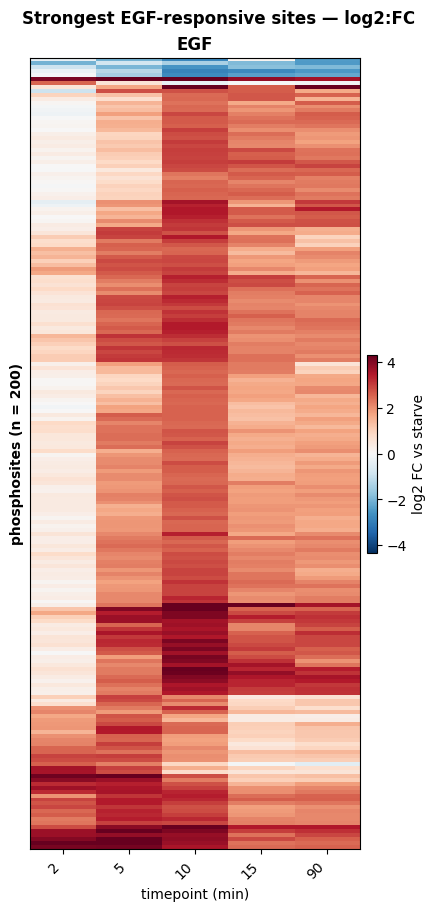

In [8]:
fig_fc, _ = plot_fc_heatmap(hme1_2,
                         cell_line=CELL_LINE,
                         conditions=CONDITIONS,
                         sites=top_sites,
                         timepoints=["2", "5", "10", "15", "90"],
                         sort_by="hierarchical",
                         title="Strongest EGF-responsive sites — log2:FC",
                         max_sites=None)

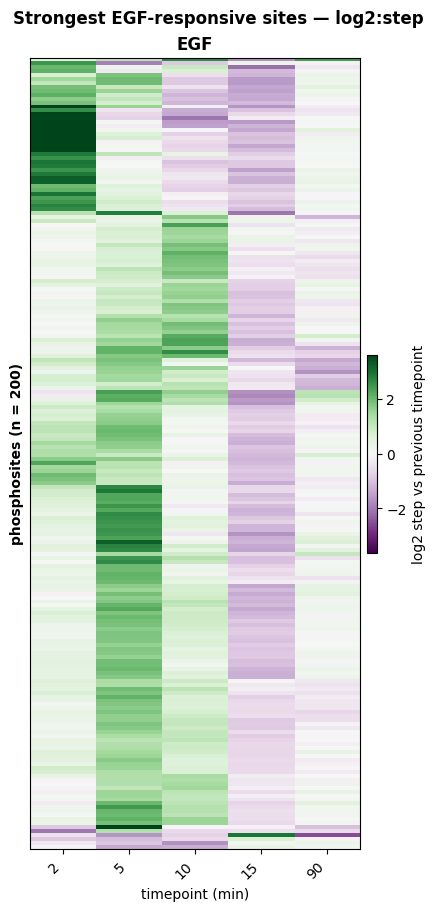

In [9]:
fig_step, _ = plot_step_heatmap(hme1_2,
                           cell_line=CELL_LINE,
                           conditions=CONDITIONS,
                           sites=top_sites,
                           timepoints=["2", "5", "10", "15", "90"],
                           sort_by="hierarchical",
                           title="Strongest EGF-responsive sites — log2:step",
                           max_sites= None)

> ⚠️ **Read the near-uniform red with the normalisation defect in mind.** No sample-loading
> normalisation is applied anywhere in the pipeline yet: the `raw:abs` column medians span
> 1.09 log2 (2.1-fold), which shifts the whole `log2:FC` distribution up — median +0.566 across
> *all* sites at EGF 5 min (`CLAUDE.md` → Known issues, and `clustering_method_decision.md` §1).
> A heatmap makes that shift very visible as an overall warm cast, and it is a property of the
> loading, not of the biology. `log2:step` is much less affected: a constant per-sample offset
> mostly cancels in the difference between two timepoints, though it does not cancel exactly,
> since each timepoint carries its own offset.


### The same comparison on the full responsive set

Ordered on `log2:step` this time, so the rows group by **when** each site moves. The FC block
on the left shows how little that timing information survives when everything is measured
against one fixed baseline: sites that rise at 2 min and sites that rise at 10 min both end up
as broad red bands, while the step block separates them into distinct horizontal blocks.